In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')  # Force le thème par défaut (fond blanc)
plt.rcParams["figure.facecolor"] = "white"  # fond de la figure
plt.rcParams["axes.facecolor"] = "white"    # fond des axes

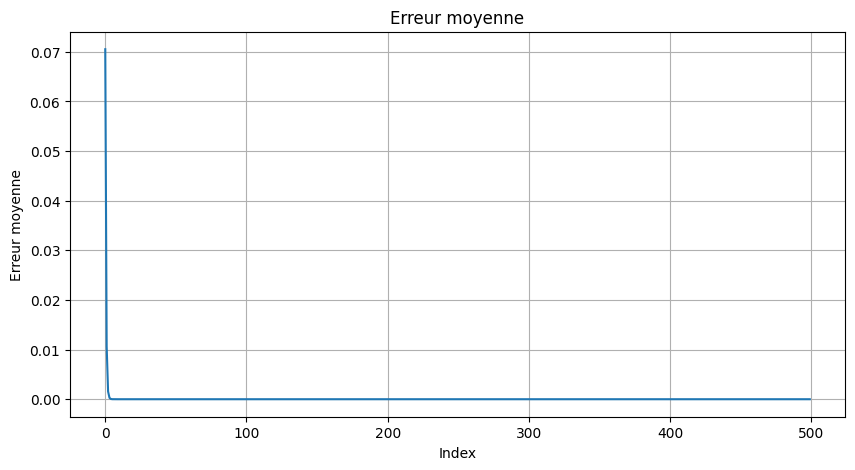

In [65]:
# Charger le fichier CSV
df = pd.read_csv('problemes.csv')

# Tracer la colonne "erreur moyenne"
plt.figure(figsize=(10, 5))
plt.plot(df[' erreur moyenne'])
plt.title('Erreur moyenne')
plt.xlabel('Index')
plt.ylabel('Erreur moyenne')
plt.grid(True)
plt.show()

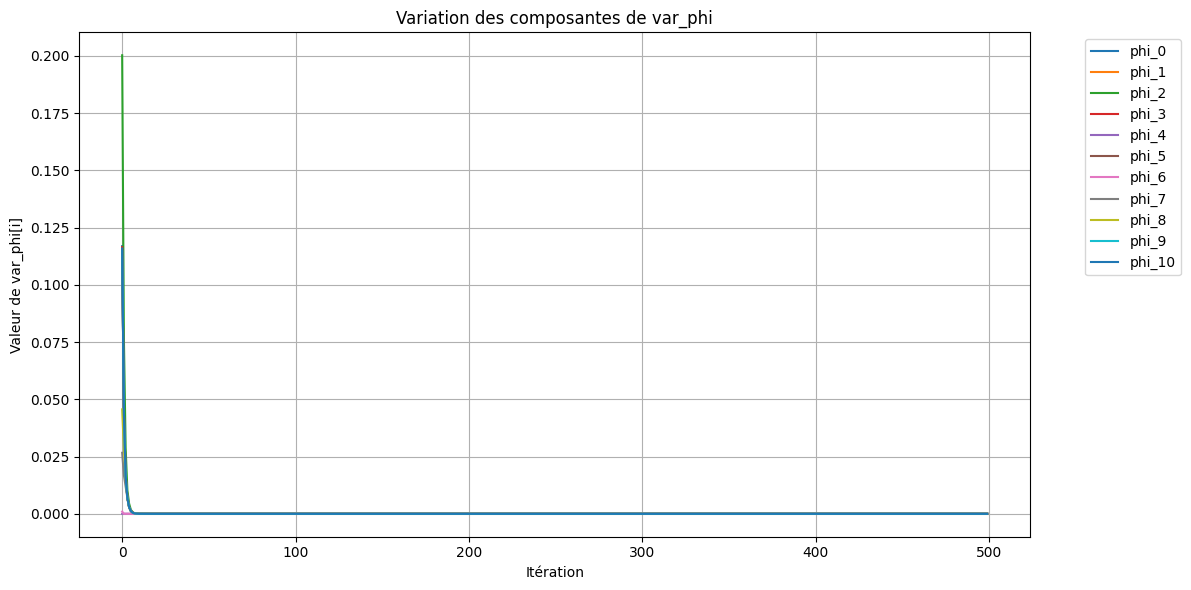

In [72]:
# On suppose que les valeurs sont séparées par des espaces
# Crée un DataFrame temporaire avec chaque valeur dans une colonne
phi_split = df["var_phi"].str.strip().str.split(" ", expand=True).astype(float)

# Renommer les colonnes : phi_0, phi_1, ..., phi_n
phi_split.columns = [f"phi_{i}" for i in range(phi_split.shape[1])]

# Fusionner avec l'itération ou d'autres colonnes si besoin
df_phi = pd.concat([df["iteration"], phi_split], axis=1)


plt.figure(figsize=(12, 6))

for i in range(0, phi_split.shape[1]):
    plt.plot(df["iteration"], df_phi[f"phi_{i}"], label=f"phi_{i}")

plt.xlabel("Itération")
plt.ylabel("Valeur de var_phi[i]")
plt.title("Variation des composantes de var_phi")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

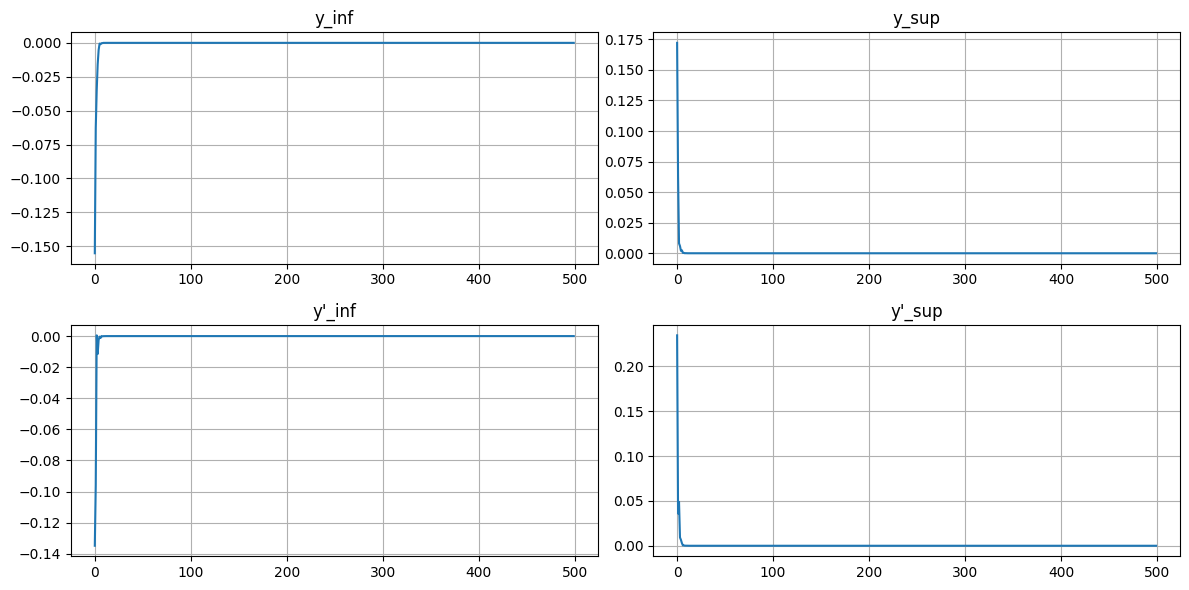

In [75]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(df['y_inf'])
plt.title("y_inf")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(df['y_sup'])
plt.title("y_sup")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(df["y'_inf"])
plt.title("y'_inf")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(df[" y'_sup"])
plt.title("y'_sup")
plt.grid()

plt.tight_layout()
plt.show()

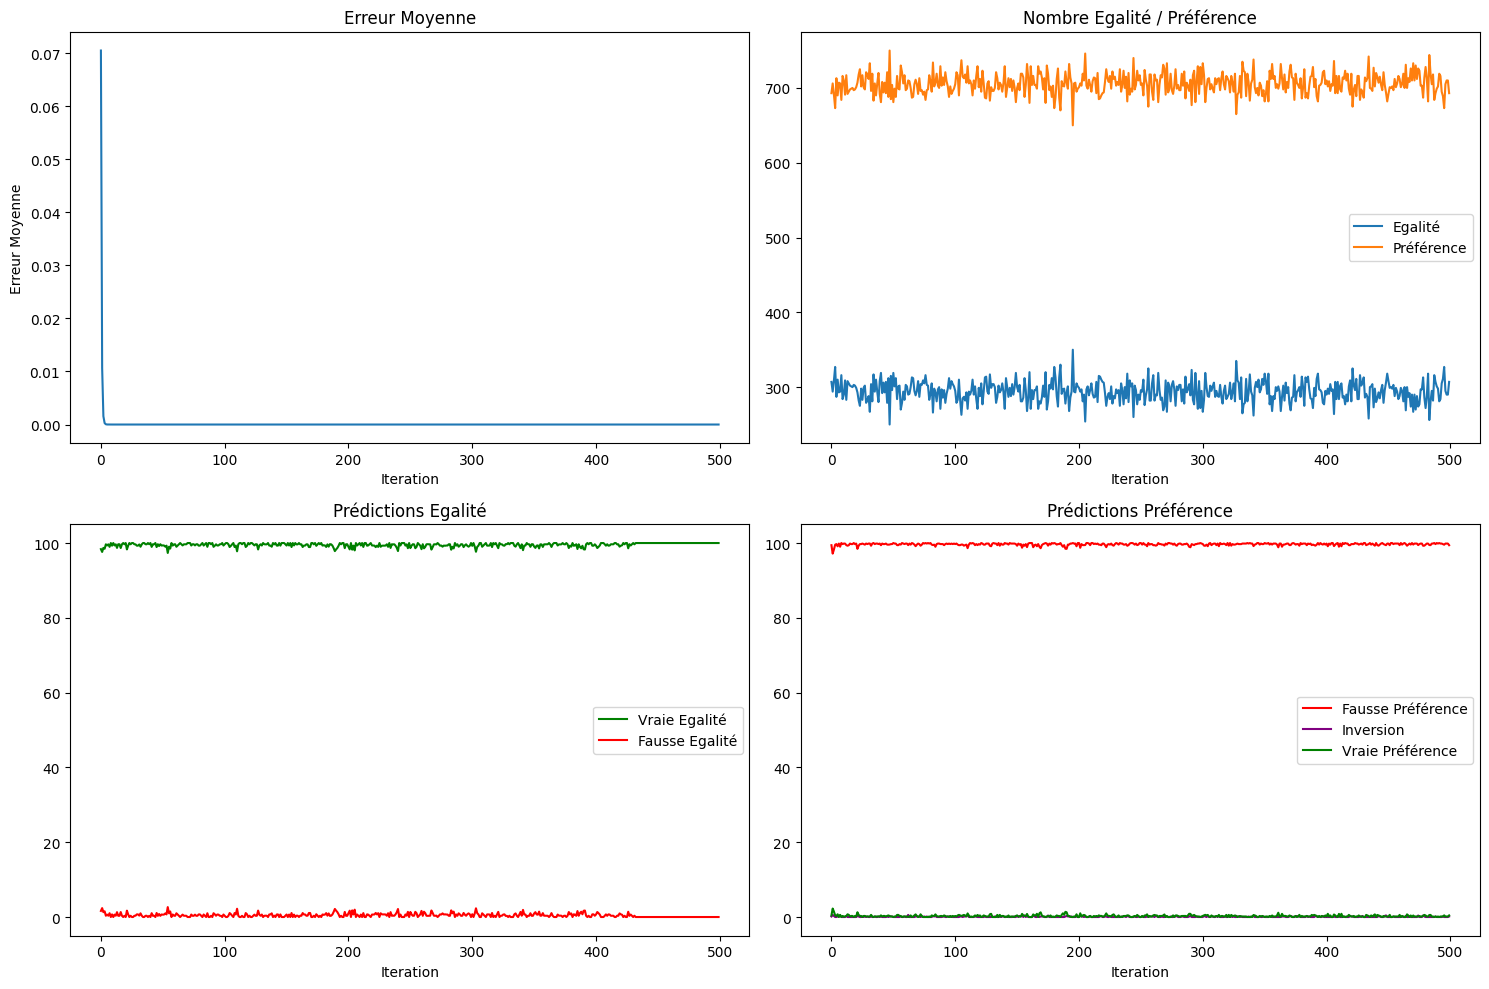

In [68]:
# Charger le fichier training_log.csv
df_train = pd.read_csv('training_log.csv')

# Créer un subplot pour visualiser les colonnes demandées
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df_train['iteration'], df_train['erreur_moy'])
plt.title("Erreur Moyenne")
plt.xlabel("Iteration")
plt.ylabel("Erreur Moyenne")

plt.subplot(2, 2, 2)
plt.plot(df_train['iteration'], df_train['nombre_egalite'], label='Egalité')
plt.plot(df_train['iteration'], df_train['nombre_preference'], label='Préférence')
plt.title("Nombre Egalité / Préférence")
plt.xlabel("Iteration")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df_train['iteration'], df_train['pred_vrai_egalite'] / df_train['nombre_egalite'] * 100, label='Vraie Egalité', color="green")
plt.plot(df_train['iteration'], df_train['pred_fausse_egalite'] / df_train['nombre_egalite'] * 100, label='Fausse Egalité', color="red")
plt.title("Prédictions Egalité")
plt.xlabel("Iteration")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(df_train['iteration'], df_train['pred_fausse_preference'] / df_train['nombre_preference'] * 100, label='Fausse Préférence', color="red")
plt.plot(df_train['iteration'], df_train['pred_fausse_inversion'] / df_train['nombre_preference'] * 100, label='Inversion', color="purple")
plt.plot(df_train['iteration'], df_train['pred_vrai_preference'] / df_train['nombre_preference'] * 100, label='Vraie Préférence', color="green") 
plt.title("Prédictions Préférence")
plt.xlabel("Iteration")
plt.legend()

plt.tight_layout()
plt.show()

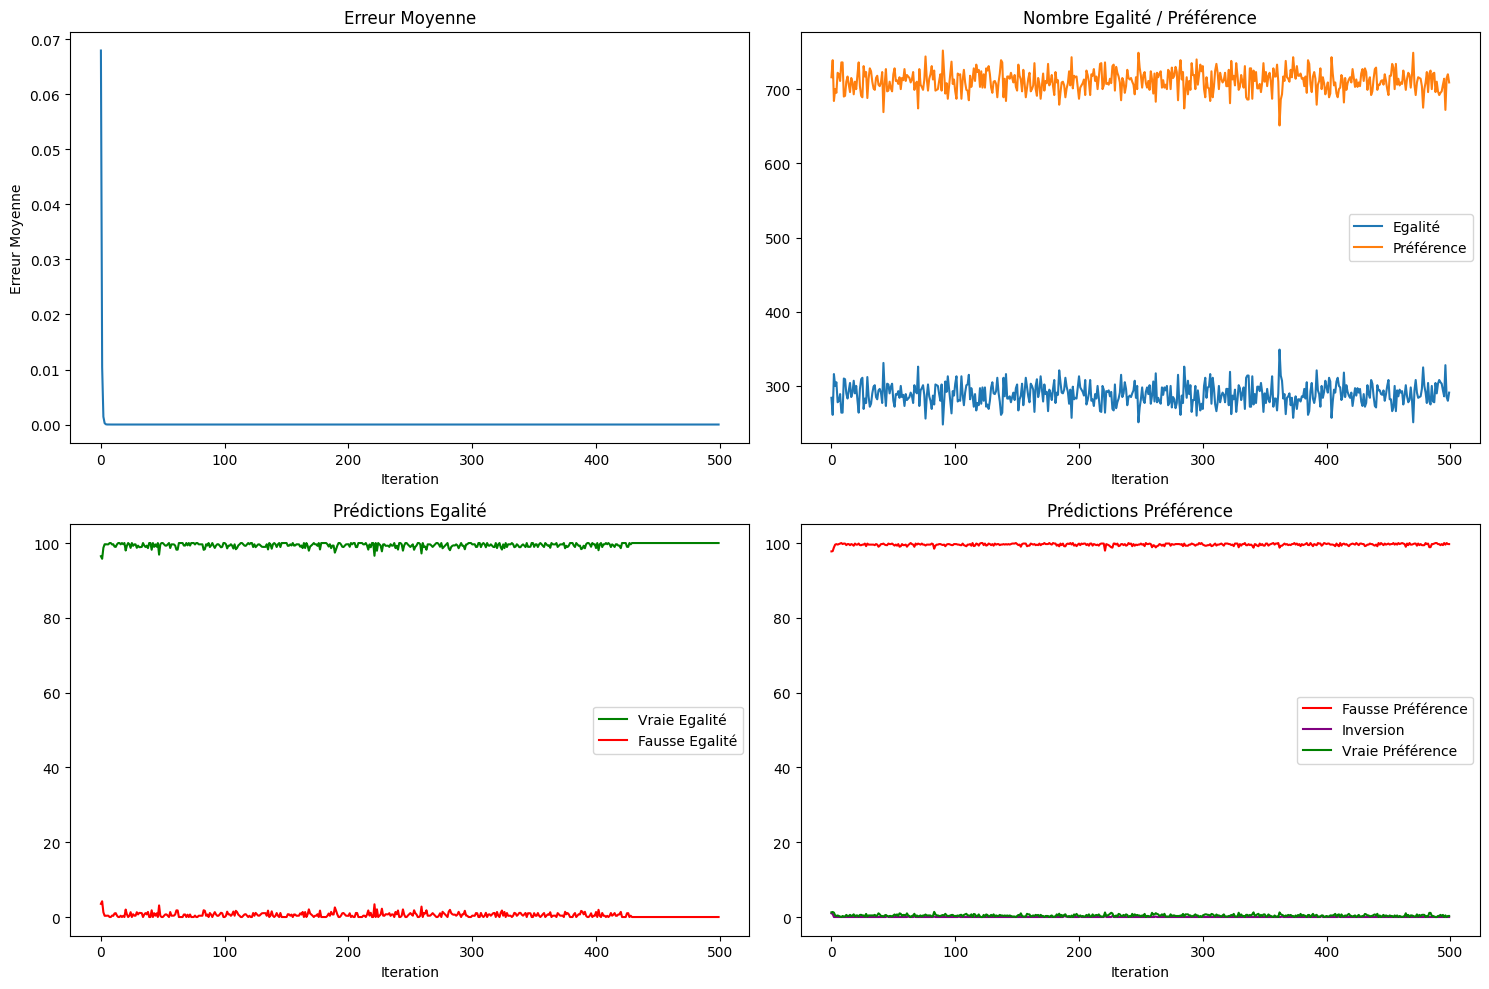

In [69]:
# Charger le fichier test_log.csv
df_test = pd.read_csv('test_log.csv')

# Créer un subplot pour visualiser les colonnes demandées
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df_test['iteration'], df_test['erreur_moy'])
plt.title("Erreur Moyenne")
plt.xlabel("Iteration")
plt.ylabel("Erreur Moyenne")

plt.subplot(2, 2, 2)
plt.plot(df_test['iteration'], df_test['nombre_egalite'], label='Egalité')
plt.plot(df_test['iteration'], df_test['nombre_preference'], label='Préférence')
plt.title("Nombre Egalité / Préférence")
plt.xlabel("Iteration")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df_test['iteration'], df_test['pred_vrai_egalite'] * 100 / df_test['nombre_egalite'], label='Vraie Egalité', color="green")
plt.plot(df_test['iteration'], df_test['pred_fausse_egalite'] * 100 / df_test['nombre_egalite'], label='Fausse Egalité', color="red")
plt.title("Prédictions Egalité")
plt.xlabel("Iteration")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(df_test['iteration'], df_test['pred_fausse_preference'] * 100 / df_test['nombre_preference'], label='Fausse Préférence', color="red")
plt.plot(df_test['iteration'], df_test['pred_fausse_inversion'] * 100 / df_test['nombre_preference'], label='Inversion', color="purple")
plt.plot(df_test['iteration'], df_test['pred_vrai_preference'] * 100 / df_test['nombre_preference'], label='Vraie Préférence', color="green") 
plt.title("Prédictions Préférence")
plt.xlabel("Iteration")
plt.legend()

plt.tight_layout()
plt.show()

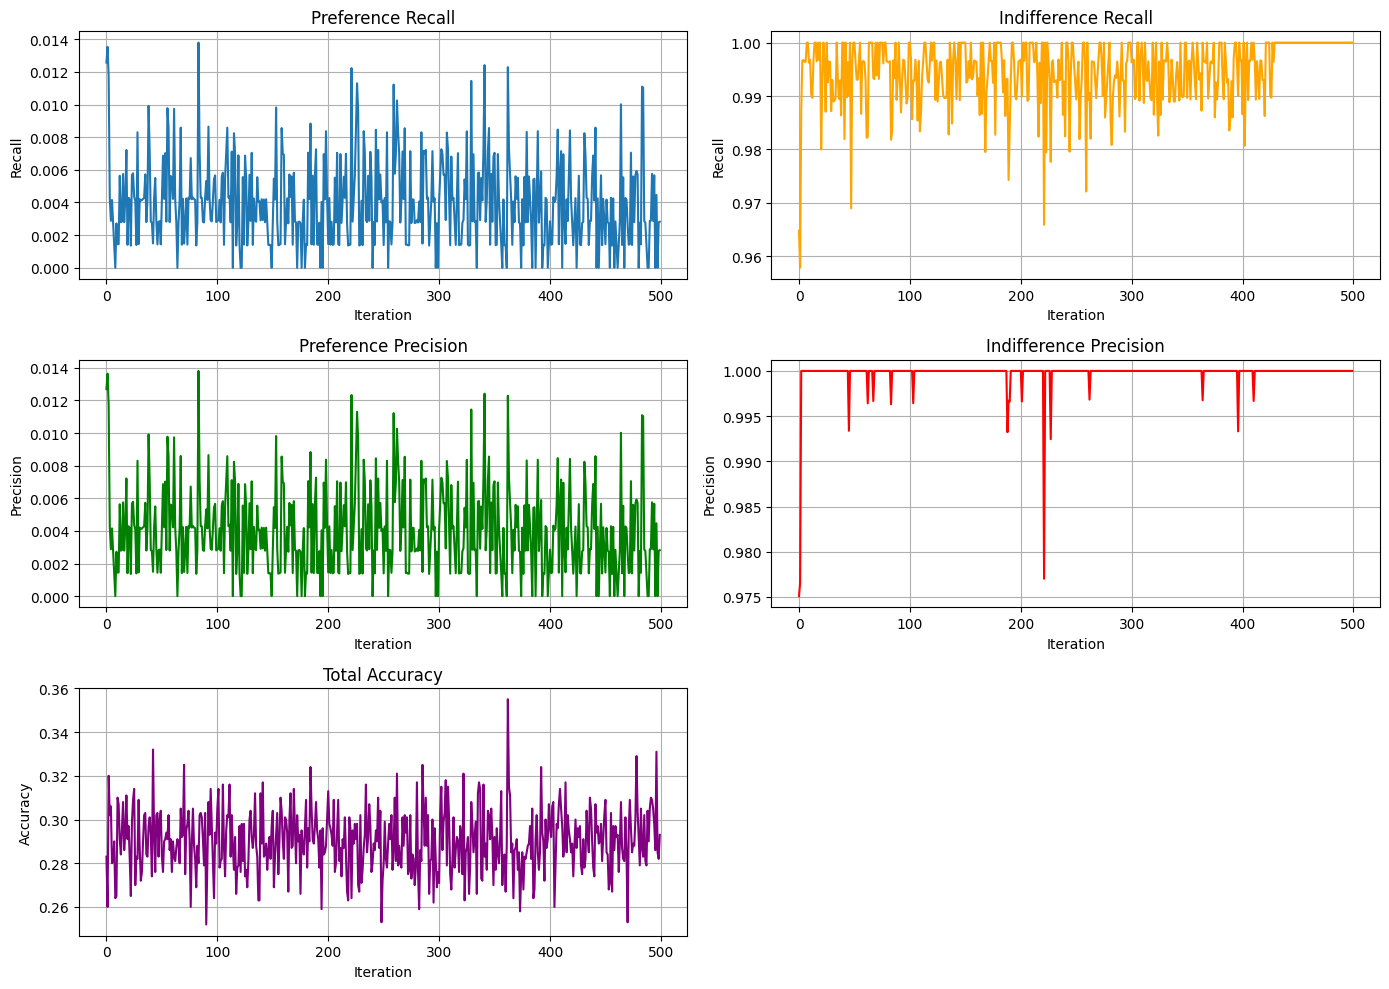

In [76]:
# Calcul des métriques pour chaque ligne de df_test
nb_indifferences = df_test["nombre_egalite"]
nb_preferences = df_test["nombre_preference"]
nb_indiff_vrai = df_test["pred_vrai_egalite"]
nb_indiff_fausse = df_test["pred_fausse_egalite"]
nb_pref_vrai = df_test["pred_vrai_preference"]
nb_pref_fausse = df_test["pred_fausse_preference"]
nb_pref_inverse = df_test["pred_fausse_inversion"]

preference_recall = nb_pref_vrai / (nb_pref_vrai + nb_pref_fausse + nb_pref_inverse)
preference_recall = preference_recall.fillna(0)

indifference_recall = nb_indiff_vrai / (nb_indiff_vrai + nb_indiff_fausse)
indifference_recall = indifference_recall.fillna(0)

preference_precision = nb_pref_vrai / (nb_pref_vrai + nb_pref_fausse)
preference_precision = preference_precision.fillna(0)

indifference_precision = nb_indiff_vrai / (nb_indiff_vrai + nb_pref_inverse)
indifference_precision = indifference_precision.fillna(0)

total = nb_indifferences + nb_preferences
correct = nb_pref_vrai + nb_indiff_vrai
precision_total = correct / total
precision_total = precision_total.fillna(0)

plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(df_test['iteration'], preference_recall, label='Preference Recall')
plt.title('Preference Recall')
plt.xlabel('Iteration')
plt.ylabel('Recall')
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(df_test['iteration'], indifference_recall, label='Indifference Recall', color='orange')
plt.title('Indifference Recall')
plt.xlabel('Iteration')
plt.ylabel('Recall')
plt.grid()

plt.subplot(3, 2, 3)
plt.plot(df_test['iteration'], preference_precision, label='Preference Precision', color='green')
plt.title('Preference Precision')
plt.xlabel('Iteration')
plt.ylabel('Precision')
plt.grid()

plt.subplot(3, 2, 4)
plt.plot(df_test['iteration'], indifference_precision, label='Indifference Precision', color='red')
plt.title('Indifference Precision')
plt.xlabel('Iteration')
plt.ylabel('Precision')
plt.grid()

plt.subplot(3, 2, 5)
plt.plot(df_test['iteration'], precision_total, label='Total Accuracy', color='purple')
plt.title('Total Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.grid()

plt.tight_layout()
plt.show()

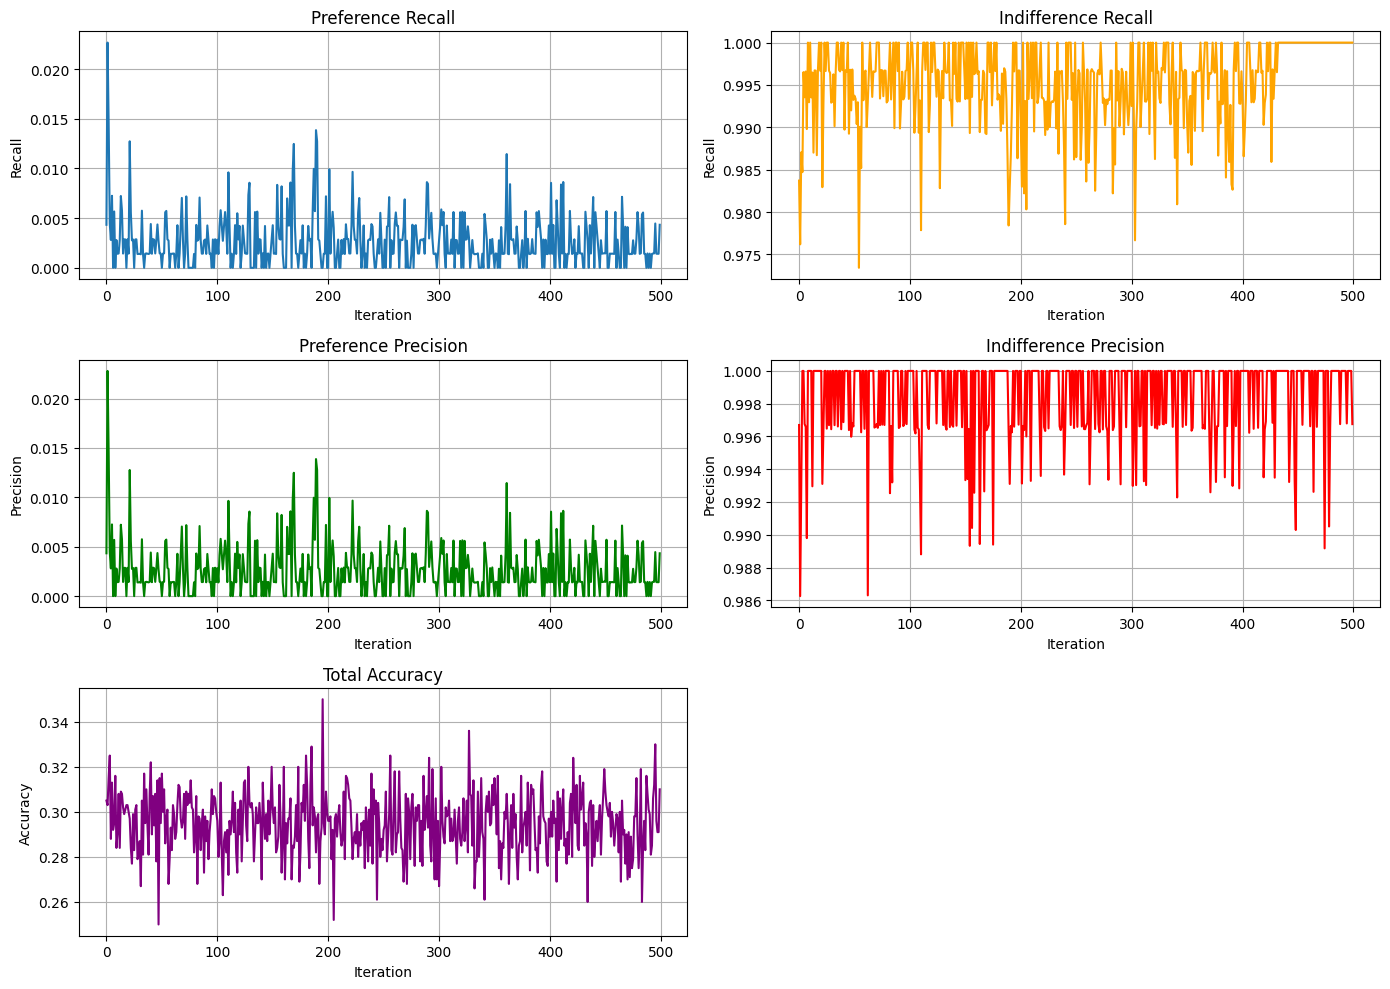

In [ ]:
# Calcul des métriques pour chaque ligne de df_test
nb_indifferences = df_train["nombre_egalite"]
nb_preferences = df_train["nombre_preference"]
nb_indiff_vrai = df_train["pred_vrai_egalite"]
nb_indiff_fausse = df_train["pred_fausse_egalite"]
nb_pref_vrai = df_train["pred_vrai_preference"]
nb_pref_fausse = df_train["pred_fausse_preference"]
nb_pref_inverse = df_train["pred_fausse_inversion"]

preference_recall = nb_pref_vrai / (nb_pref_vrai + nb_pref_fausse + nb_pref_inverse)
preference_recall = preference_recall.fillna(0)

indifference_recall = nb_indiff_vrai / (nb_indiff_vrai + nb_indiff_fausse)
indifference_recall = indifference_recall.fillna(0)

preference_precision = nb_pref_vrai / (nb_pref_vrai + nb_pref_fausse)
preference_precision = preference_precision.fillna(0)

indifference_precision = nb_indiff_vrai / (nb_indiff_vrai + nb_pref_inverse)
indifference_precision = indifference_precision.fillna(0)

total = nb_indifferences + nb_preferences
correct = nb_pref_vrai + nb_indiff_vrai
precision_total = correct / total
precision_total = precision_total.fillna(0)

plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(df_train['iteration'], preference_recall, label='Preference Recall')
plt.title('Preference Recall')
plt.xlabel('Iteration')
plt.ylabel('Recall')
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(df_train['iteration'], indifference_recall, label='Indifference Recall', color='orange')
plt.title('Indifference Recall')
plt.xlabel('Iteration')
plt.ylabel('Recall')
plt.grid()

plt.subplot(3, 2, 3)
plt.plot(df_train['iteration'], preference_precision, label='Preference Precision', color='green')
plt.title('Preference Precision')
plt.xlabel('Iteration')
plt.ylabel('Precision')
plt.grid()

plt.subplot(3, 2, 4)
plt.plot(df_train['iteration'], indifference_precision, label='Indifference Precision', color='red')
plt.title('Indifference Precision')
plt.xlabel('Iteration')
plt.ylabel('Precision')
plt.grid()

plt.subplot(3, 2, 5)
plt.plot(df_train['iteration'], precision_total, label='Total Accuracy', color='purple')
plt.title('Total Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.grid()

plt.tight_layout()
plt.show()